11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Creating VAE model...
Training VAE...
Epoch 1/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - kl_loss: 26.3150 - loss: 368.7968 - reconstruction_loss: 342.4817
Epoch 2/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 12.7401 - loss: 207.1679 - reconstruction_loss: 194.4278
Epoch 3/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 7.9821 - loss: 193.1871 - reconstruction_loss: 185.2050
Epoch 4/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 6.3576 - loss: 187.6768 - reconstruction_loss: 181.3192
Epoch 5/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.6684 - loss: 183.7519 - reconstruction_loss: 178.0835
Epoch 6/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.3003 - loss: 179.0604 - reconstruction_loss: 173.7601
Epoch 7/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.9623 - loss: 176.2340 - reconstruction_loss: 171.2717

Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


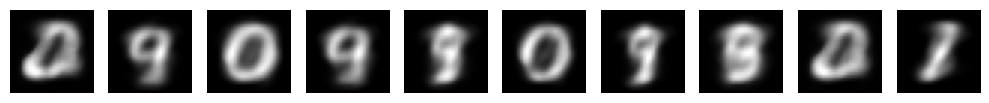

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess MNIST data
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))

# Network parameters
input_shape = (28, 28, 1)
batch_size = 128
latent_dim = 2
intermediate_dim = 512
epochs = 7

class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        z_mean = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        return z_mean

# Encoder
encoder_inputs = Input(shape=input_shape)
x = Flatten()(encoder_inputs)
x = Dense(intermediate_dim, activation='relu')(x)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
decoder_inputs = Input(shape=(latent_dim,))
x = Dense(intermediate_dim, activation='relu')(decoder_inputs)
x = Dense(784, activation='sigmoid')(x)
decoder_outputs = Reshape((28, 28, 1))(x)
decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Encoder output
            z_mean, z_log_var, z = self.encoder(data)
            # Reconstruction
            reconstruction = self.decoder(z)

            # Flatten input and reconstruction for binary crossentropy
            flat_data = tf.reshape(data, (-1, 784))
            flat_reconstruction = tf.reshape(reconstruction, (-1, 784))

            # Reconstruction loss (fixed axis handling)
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    flat_data,
                    flat_reconstruction
                )
            ) * 784

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

# Create and compile VAE
def create_and_compile_vae(encoder, decoder):
  print("Creating VAE model...")
  vae = VAE(encoder, decoder)
  vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))
  return vae


def generate_digits(decoder, n=10):
    """Generate n new digits using the decoder"""
    z_sample = np.random.normal(size=(n, latent_dim))
    x_decoded = decoder.predict(z_sample)
    return x_decoded

# To visualize the generated digits
def plotDigits(digits):
  plt.figure(figsize=(10, 2))
  for i in range(10):
      plt.subplot(1, 10, i + 1)
      plt.imshow(digits[i].reshape(28, 28), cmap='gray')
      plt.axis('off')
  plt.tight_layout()
  plt.show()

vae = create_and_compile_vae(encoder, decoder)
# Train VAE
print("Training VAE...")
vae.fit(x_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True)

# After training the VAE, you can use it like this:
print("\nGenerating new digits...")
new_digits = generate_digits(decoder, 10)  # Generates 10 new digits
plotDigits(new_digits)  # Plots the generated digits

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


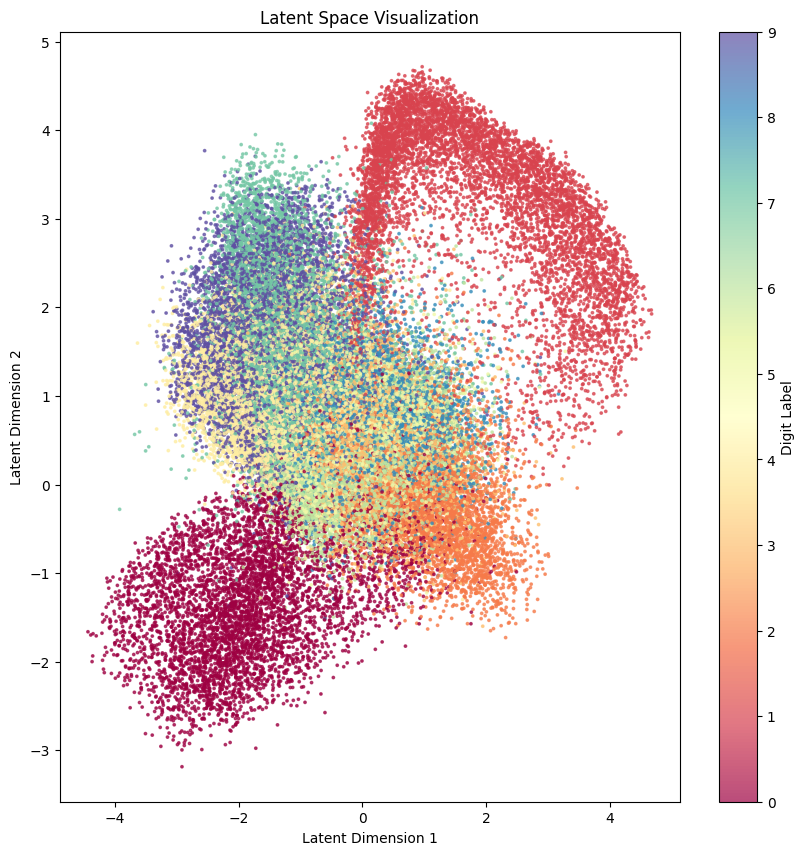

In [2]:
#Task 1: Visualise the latent space
import matplotlib as mpl
def visualize_latent_space(encoder, x_train, y_train):
    z_mean, _, _ = encoder.predict(x_train)

    cmap = mpl.colormaps["Spectral"] # Use a distinct colormap for categories
    plt.figure(figsize=(10, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_train, cmap=cmap, s=3, alpha=0.7)
    plt.colorbar(label='Digit Label') # Add a colorbar to indicate the mapping
    plt.title('Latent Space Visualization')
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.show()

visualize_latent_space(encoder, x_train, y_train)


Training VAE with epochs 5

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8190 - loss: 174.2114 - reconstruction_loss: 169.3924
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.7758 - loss: 172.2096 - reconstruction_loss: 167.4339
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.7969 - loss: 170.7664 - reconstruction_loss: 165.9696
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.7839 - loss: 170.0488 - reconstruction_loss: 165.2649
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.8054 - loss: 169.3508 - reconstruction_loss: 164.5454
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


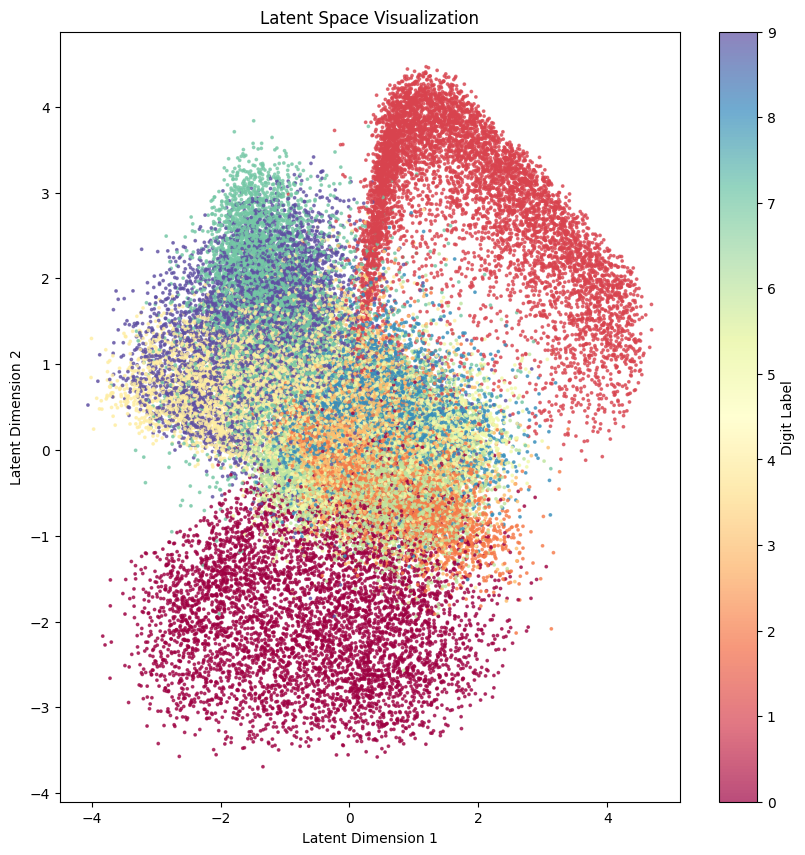


Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


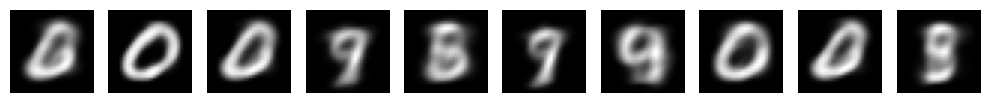


Training VAE with epochs 15

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.8281 - loss: 168.3292 - reconstruction_loss: 163.5010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8560 - loss: 167.7555 - reconstruction_loss: 162.8994
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8918 - loss: 166.8902 - reconstruction_loss: 161.9984
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.9049 - loss: 166.2983 - reconstruction_loss: 161.3934
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.9022 - loss: 165.8925 - reconstruction_loss: 160.9904
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.9232 - loss: 165.6471 - reconstruction_loss: 160.7239
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.9685 - loss: 164.9259 - reconstruction_loss: 159.9574
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.9718 - loss: 164.8704 - reconstruction_loss: 159.8986
Epoch 9/15
469/469

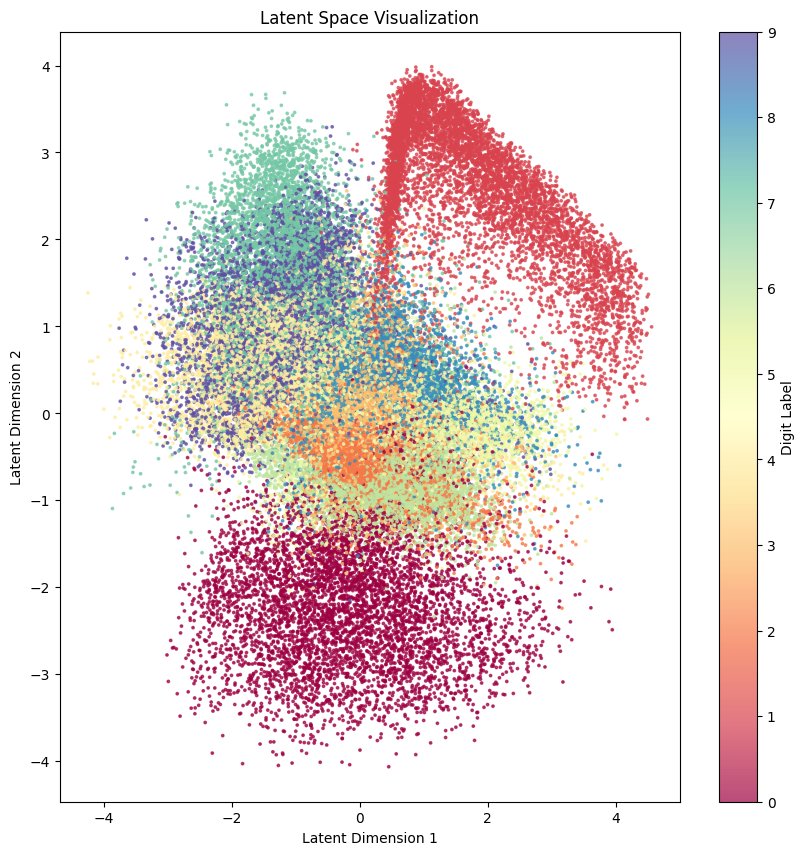


Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


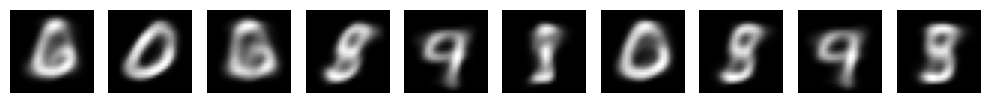


Training VAE with epochs 30

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.1116 - loss: 162.2105 - reconstruction_loss: 157.0989
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 5.1290 - loss: 162.1342 - reconstruction_loss: 157.0052
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.1611 - loss: 161.8316 - reconstruction_loss: 156.6706
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.1552 - loss: 161.8294 - reconstruction_loss: 156.6743
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.1870 - loss: 161.0719 - reconstruction_loss: 155.8848
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.1822 - loss: 160.8999 - reconstruction_loss: 155.7176
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.1898 - loss: 160.5295 - reconstruction_loss: 155.3397
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.2115 - loss: 160.6628 - reconstruction_loss: 155.4513
Epoch 9/30
469/469

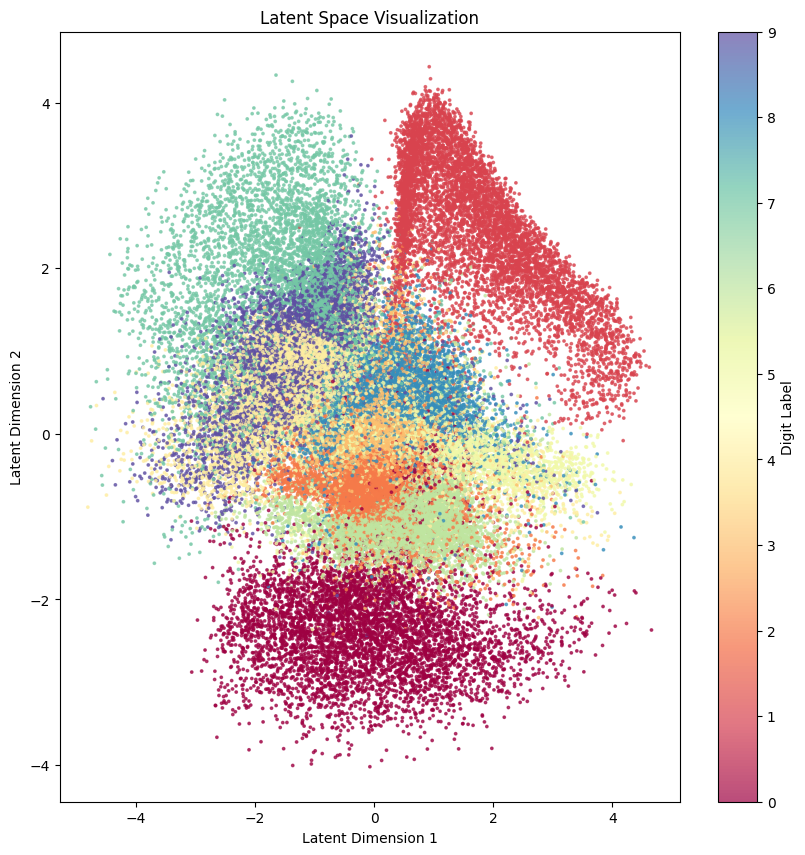


Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


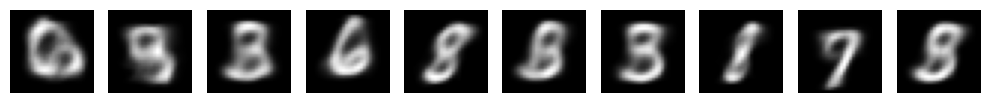

In [3]:
#Task 2: Change epochs
epochs_set = [5, 15, 30]

for epochs in epochs_set:

  # Train VAE
  print(f"\nTraining VAE with epochs {epochs}\n")
  vae.fit(x_train,
          epochs=epochs,
          batch_size=batch_size,
          shuffle=True)
  visualize_latent_space(encoder, x_train, y_train)

  # After training the VAE, you can use it like this:
  print("\nGenerating new digits...")
  new_digits = generate_digits(decoder, 10)  # Generates 10 new digits
  plotDigits(new_digits)  # Plots the generated digits

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.6224 - loss: 155.9884 - reconstruction_loss: 150.3660
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.6330 - loss: 155.7930 - reconstruction_loss: 150.1600
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.6314 - loss: 155.6747 - reconstruction_loss: 150.0433
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.6346 - loss: 155.4661 - reconstruction_loss: 149.8315
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.6468 - loss: 155.4505 - reconstruction_loss: 149.8037
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.6623 - loss: 155.5710 - reconstruction_loss: 149.9087
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.6477 - loss: 155.1901 - reconstruction_loss: 149.5424
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.6811 - loss: 155.0642 - reconstruction_loss: 149.3832
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/s

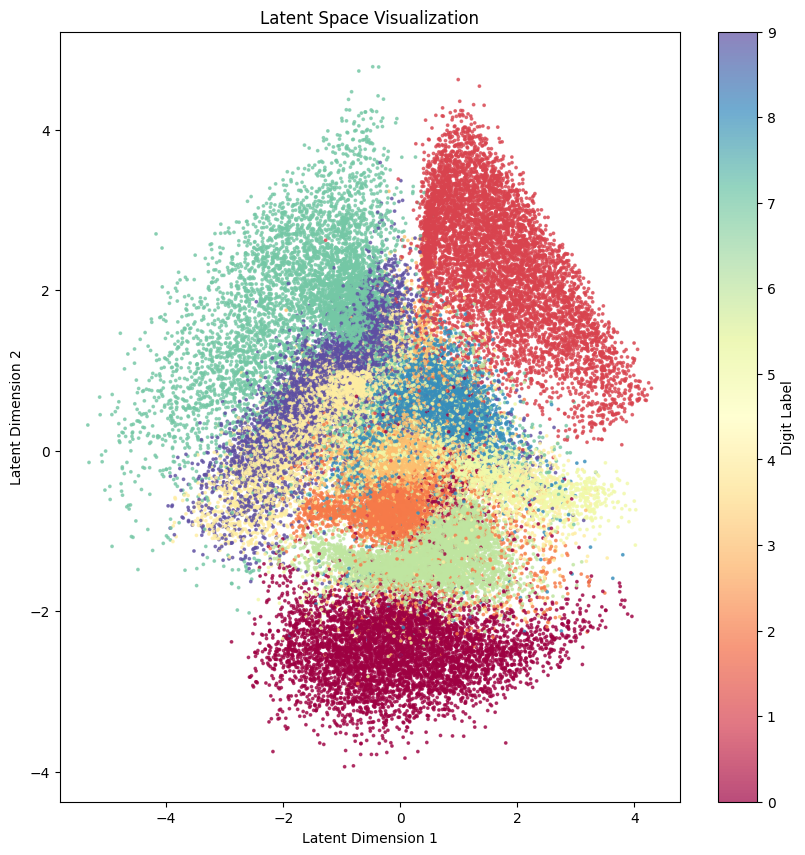


Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


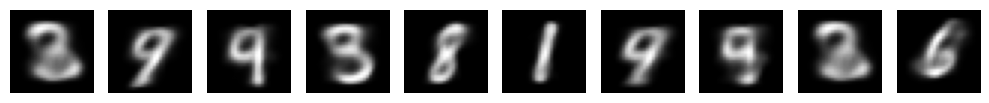

In [5]:
vae.fit(x_train,
          epochs=50,
          batch_size=batch_size,
          shuffle=True)
visualize_latent_space(encoder, x_train, y_train)

# After training the VAE, you can use it like this:
print("\nGenerating new digits...")
new_digits = generate_digits(decoder, 10)  # Generates 10 new digits
plotDigits(new_digits)

##Task 3: Analyse the output

###Briefly describe how the latent space has changed with the number of epochs (Approx. 100 words)
As the number of epochs for training are increased the clusters in the latent space seem to have low overlap and low internal scatter (tightness) which means they are well-separated. This structure indicates that the encoder is learning to map similar input data points to distinct, compact regions in the latent space, reducing ambiguity for the decoder as the number of training iterations are increased. For example when epochs are set to 5, data points representing labels 0 to 1 were well separated but 2 to 9 had lot of overlap. When epochs are set to 15, labels 8 and 7 seem to be well seperated when compared to 5 epochs. When set to 30, the variance within clusters has reduced vastly.

###Briefly describe how the quality of generated digits has changed with the number of epochs (Approx. 100 words)
The quality of the generated digit by decoder will depend on where the sample is picked from. If it is picked from the "empty" space between two distant, tight clusters, or from the space where there is overlap the decoder might produce low-quality, blurry images. As the increase in epochs resulted in more well-seperated clusters, it is observed that the quality of few generated digits was good. For example the generated digits after training with epochs 5, digit 0 had good quality. After training with epochs 15, digit 8 was generated with higher quality. After 30 epochs of training more numbers are generated with relatively higher quality than earlier.


###What would happen if you try 50 or 100 epochs? Does the model get better or worse?

As observed in the training output as the number of epochs are increased the KL loss tends to be increasing after few epochs. This indicates that the model is prioritizing reconstruction accuracy over the regularization of its latent space (latent distribution is moving further away from the intended prior), often leading to the latent space becoming too restrictive or "over-fitted" to the training data.  